In [8]:
import mynn
from draw_tools.plot import plot
import numpy as np
from struct import unpack
import pickle
import gzip
import matplotlib.pyplot as plt

# fixed seed for experiment
np.random.seed(309)

train_images_path = r'.\dataset\MNIST\train-images-idx3-ubyte.gz'
train_labels_path = r'.\dataset\MNIST\train-labels-idx1-ubyte.gz'

with gzip.open(train_images_path, 'rb') as f:
        magic, num, rows, cols = unpack('>4I', f.read(16))
        train_imgs=np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28*28)
    
with gzip.open(train_labels_path, 'rb') as f:
        magic, num = unpack('>2I', f.read(8))
        train_labs = np.frombuffer(f.read(), dtype=np.uint8)


# choose 10000 samples from train set as validation set.
idx = np.random.permutation(np.arange(num))
# save the index.
with open('idx.pickle', 'wb') as f:
        pickle.dump(idx, f)
train_imgs = train_imgs[idx]
train_labs = train_labs[idx]
valid_imgs = train_imgs[:10000]
valid_labs = train_labs[:10000]
train_imgs = train_imgs[10000:]
train_labs = train_labs[10000:]

# normalize from [0, 255] to [0, 1]
train_imgs = train_imgs / train_imgs.max()
valid_imgs = valid_imgs / valid_imgs.max()



In [ ]:
def train_model(nHidden, lr=0.5, epochs=100,early_stop=8, initialize_method='He'):
    # 模型结构：输入层 + 隐藏层 + 输出层
    size_list = [train_imgs.shape[1]] + nHidden + [10]
    lambda_list = [1e-4] * (len(nHidden) + 1)  # 每层一个lambda
    
    # 初始化组件
    model = mynn.models.Model_MLP(size_list, 'ReLU', lambda_list, dropout_p=None, initialize_method=initialize_method)
    my_optimizer = mynn.optimizer.MomentGD(init_lr=lr, model=model, mu=0.9)
    scheduler = mynn.lr_scheduler.MultiStepLR(my_optimizer, milestones=[8000, 70000, 80000], gamma=0.5)

    loss_fn = mynn.op.MultiCrossEntropyLoss(model=model)
    
    
    # 训练运行器
    trainer = mynn.runner.RunnerM(
        model=model,
        optimizer=my_optimizer,
        metric=mynn.metric.accuracy,
        loss_fn=loss_fn,
        batch_size=32,
        scheduler=scheduler
    )
    
    # 执行训练
    trainer.train(
        train_set=[train_imgs, train_labs],
        dev_set=[valid_imgs, valid_labs],
        num_epochs=epochs,
        log_epochs=1,
        early_stop = early_stop,
        save_dir = f'./saved_models/Q1/hidden_{"_".join(map(str, nHidden))}_{initialize_method}'
    )
    
    _, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 绘制训练和验证损失曲线
    axes[0].plot(trainer.train_loss, label='Train Loss')
    axes[0].plot(trainer.dev_loss, label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epochs')  # x轴标签
    axes[0].set_ylabel('Loss')    # y轴标签
    axes[0].legend()

    # 绘制训练和验证准确度曲线
    axes[1].plot(trainer.train_scores, label='Train Acc')
    axes[1].plot(trainer.dev_scores, label='Val Acc')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Epochs')  # x轴标签
    axes[1].set_ylabel('Accuracy')  # y轴标签
    axes[1].legend()

    plt.tight_layout()  # 自动调整布局
    plt.show()
    
    return trainer

## nHidden = 16

best accuracy performence has been updated: 0.00000 --> 0.91070
Epoch 1/100:
[Train] loss: 0.41981, score: 0.87368
[Dev] loss: 0.30376, score: 0.91070
best accuracy performence has been updated: 0.91070 --> 0.91940
Epoch 2/100:
[Train] loss: 0.29617, score: 0.91361
[Dev] loss: 0.28309, score: 0.91940
Epoch 3/100:
[Train] loss: 0.27392, score: 0.92039
[Dev] loss: 0.29484, score: 0.91580
best accuracy performence has been updated: 0.91940 --> 0.92290
Epoch 4/100:
[Train] loss: 0.26332, score: 0.92376
[Dev] loss: 0.25889, score: 0.92290
best accuracy performence has been updated: 0.92290 --> 0.92350
Epoch 5/100:
[Train] loss: 0.25793, score: 0.92400
[Dev] loss: 0.27006, score: 0.92350
best accuracy performence has been updated: 0.92350 --> 0.92850
Epoch 6/100:
[Train] loss: 0.23745, score: 0.93304
[Dev] loss: 0.24755, score: 0.92850
Epoch 7/100:
[Train] loss: 0.23275, score: 0.93458
[Dev] loss: 0.25162, score: 0.92730
Epoch 8/100:
[Train] loss: 0.23195, score: 0.93440
[Dev] loss: 0.25065,

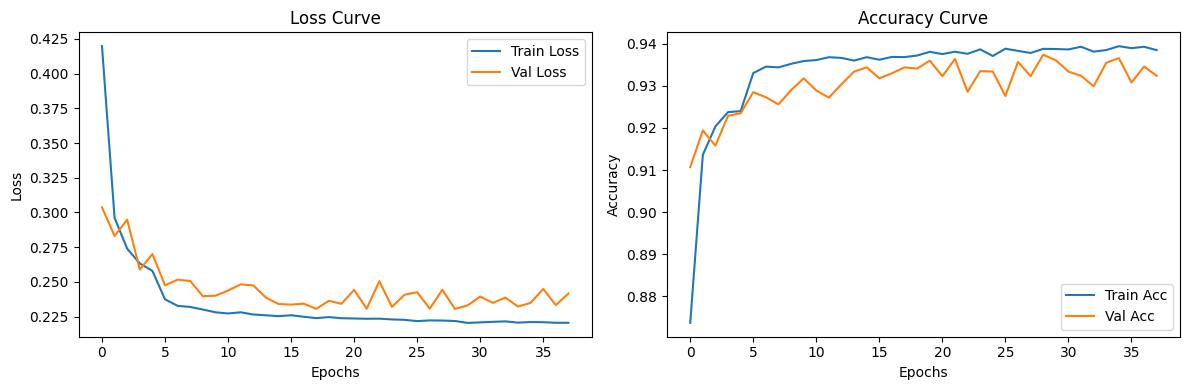

Best train set accuracy: 0.9394393793985925
Best validation set accuracy: 0.9374


In [10]:
nHidden = [16]
trainer_1 = train_model(nHidden)
print("Best train set accuracy:", max(trainer_1.train_scores))
print("Best validation set accuracy:", trainer_1.best_score)

## nHidden = 32

best accuracy performence has been updated: 0.00000 --> 0.93190
Epoch 1/100:
[Train] loss: 0.35275, score: 0.89735
[Dev] loss: 0.24219, score: 0.93190
best accuracy performence has been updated: 0.93190 --> 0.94210
Epoch 2/100:
[Train] loss: 0.22584, score: 0.93690
[Dev] loss: 0.21833, score: 0.94210
best accuracy performence has been updated: 0.94210 --> 0.94470
Epoch 3/100:
[Train] loss: 0.20710, score: 0.94294
[Dev] loss: 0.20291, score: 0.94470
best accuracy performence has been updated: 0.94470 --> 0.94570
Epoch 4/100:
[Train] loss: 0.19778, score: 0.94466
[Dev] loss: 0.20258, score: 0.94570
best accuracy performence has been updated: 0.94570 --> 0.94840
Epoch 5/100:
[Train] loss: 0.19519, score: 0.94656
[Dev] loss: 0.19390, score: 0.94840
best accuracy performence has been updated: 0.94840 --> 0.94960
Epoch 6/100:
[Train] loss: 0.17856, score: 0.95313
[Dev] loss: 0.19022, score: 0.94960
best accuracy performence has been updated: 0.94960 --> 0.95170
Epoch 7/100:
[Train] loss: 0.1

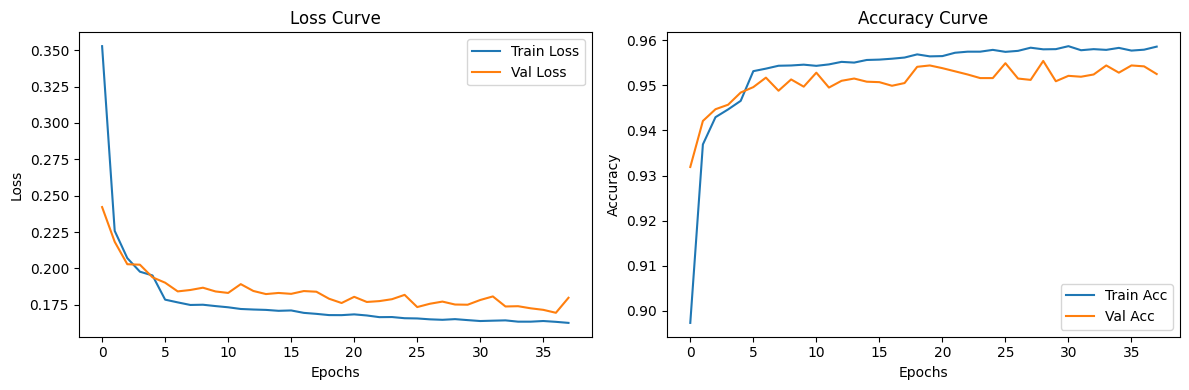

Best train set accuracy: 0.9586732245681382
Best validation set accuracy: 0.9554


In [11]:
nHidden = [32]
trainer_2 = train_model(nHidden)
print("Best train set accuracy:", max(trainer_2.train_scores))
print("Best validation set accuracy:", trainer_2.best_score)

## nHidden = 64

best accuracy performence has been updated: 0.00000 --> 0.93670
Epoch 1/100:
[Train] loss: 0.33194, score: 0.90305
[Dev] loss: 0.22470, score: 0.93670
best accuracy performence has been updated: 0.93670 --> 0.95020
Epoch 2/100:
[Train] loss: 0.20790, score: 0.94272
[Dev] loss: 0.19316, score: 0.95020
Epoch 3/100:
[Train] loss: 0.18569, score: 0.95002
[Dev] loss: 0.19400, score: 0.94710
best accuracy performence has been updated: 0.95020 --> 0.95210
Epoch 4/100:
[Train] loss: 0.17627, score: 0.95313
[Dev] loss: 0.18168, score: 0.95210
best accuracy performence has been updated: 0.95210 --> 0.95280
Epoch 5/100:
[Train] loss: 0.17144, score: 0.95495
[Dev] loss: 0.17956, score: 0.95280
best accuracy performence has been updated: 0.95280 --> 0.95340
Epoch 6/100:
[Train] loss: 0.15884, score: 0.95947
[Dev] loss: 0.17167, score: 0.95340
best accuracy performence has been updated: 0.95340 --> 0.95780
Epoch 7/100:
[Train] loss: 0.15627, score: 0.96181
[Dev] loss: 0.16594, score: 0.95780
Epoch 8

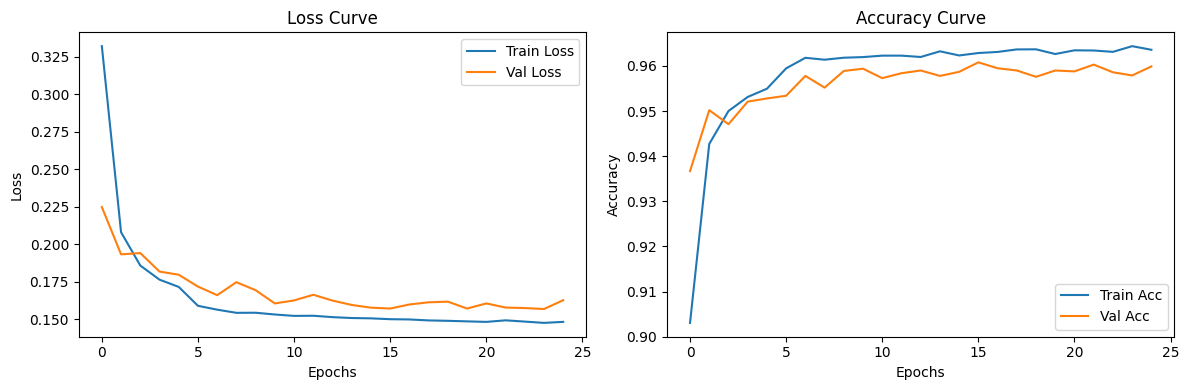

Best train set accuracy: 0.9643913947536789
Best validation set accuracy: 0.9608


In [12]:
nHidden = [64]
trainer_3 = train_model(nHidden)
print("Best train set accuracy:", max(trainer_3.train_scores))
print("Best validation set accuracy:", trainer_3.best_score)

## nHidden = 128

best accuracy performence has been updated: 0.00000 --> 0.93010
Epoch 1/100:
[Train] loss: 0.32183, score: 0.90655
[Dev] loss: 0.24551, score: 0.93010
best accuracy performence has been updated: 0.93010 --> 0.94900
Epoch 2/100:
[Train] loss: 0.19588, score: 0.94692
[Dev] loss: 0.18357, score: 0.94900
best accuracy performence has been updated: 0.94900 --> 0.95350
Epoch 3/100:
[Train] loss: 0.17520, score: 0.95302
[Dev] loss: 0.17701, score: 0.95350
best accuracy performence has been updated: 0.95350 --> 0.95360
Epoch 4/100:
[Train] loss: 0.16836, score: 0.95539
[Dev] loss: 0.17648, score: 0.95360
best accuracy performence has been updated: 0.95360 --> 0.95790
Epoch 5/100:
[Train] loss: 0.16449, score: 0.95699
[Dev] loss: 0.16843, score: 0.95790
best accuracy performence has been updated: 0.95790 --> 0.95940
Epoch 6/100:
[Train] loss: 0.15259, score: 0.96161
[Dev] loss: 0.15846, score: 0.95940
Epoch 7/100:
[Train] loss: 0.14944, score: 0.96321
[Dev] loss: 0.15899, score: 0.95900
Epoch 8

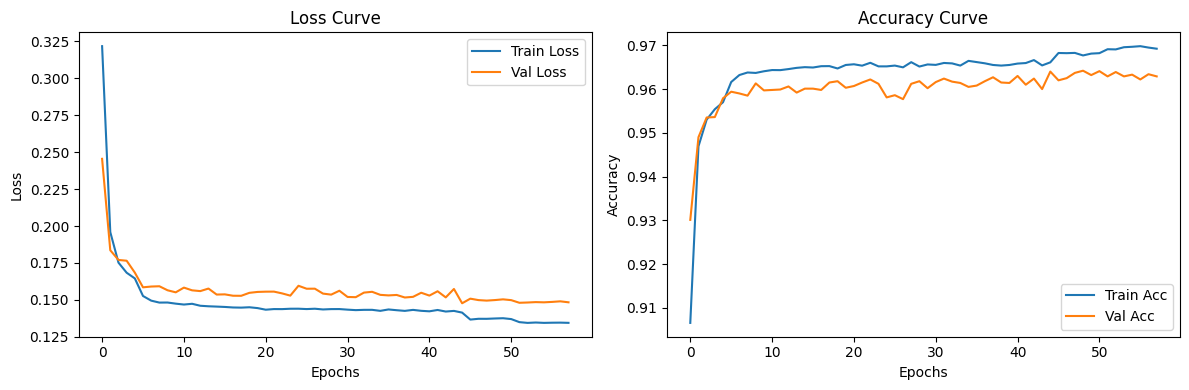

Best train set accuracy: 0.9698096609085093
Best validation set accuracy: 0.9642


In [13]:
nHidden = [128]
trainer_4 = train_model(nHidden)
print("Best train set accuracy:", max(trainer_4.train_scores))
print("Best validation set accuracy:", trainer_4.best_score)

## nHidden = [128, 128]

best accuracy performence has been updated: 0.00000 --> 0.94720
Epoch 1/100:
[Train] loss: 0.28391, score: 0.91595
[Dev] loss: 0.18771, score: 0.94720
best accuracy performence has been updated: 0.94720 --> 0.95350
Epoch 2/100:
[Train] loss: 0.16251, score: 0.95373
[Dev] loss: 0.16937, score: 0.95350
best accuracy performence has been updated: 0.95350 --> 0.95950
Epoch 3/100:
[Train] loss: 0.14371, score: 0.95979
[Dev] loss: 0.14235, score: 0.95950
best accuracy performence has been updated: 0.95950 --> 0.96130
Epoch 4/100:
[Train] loss: 0.13548, score: 0.96261
[Dev] loss: 0.14055, score: 0.96130
Epoch 5/100:
[Train] loss: 0.13235, score: 0.96339
[Dev] loss: 0.16238, score: 0.95330
best accuracy performence has been updated: 0.96130 --> 0.96470
Epoch 6/100:
[Train] loss: 0.11381, score: 0.97049
[Dev] loss: 0.12759, score: 0.96470
best accuracy performence has been updated: 0.96470 --> 0.96740
Epoch 7/100:
[Train] loss: 0.10987, score: 0.97177
[Dev] loss: 0.11942, score: 0.96740
Epoch 8

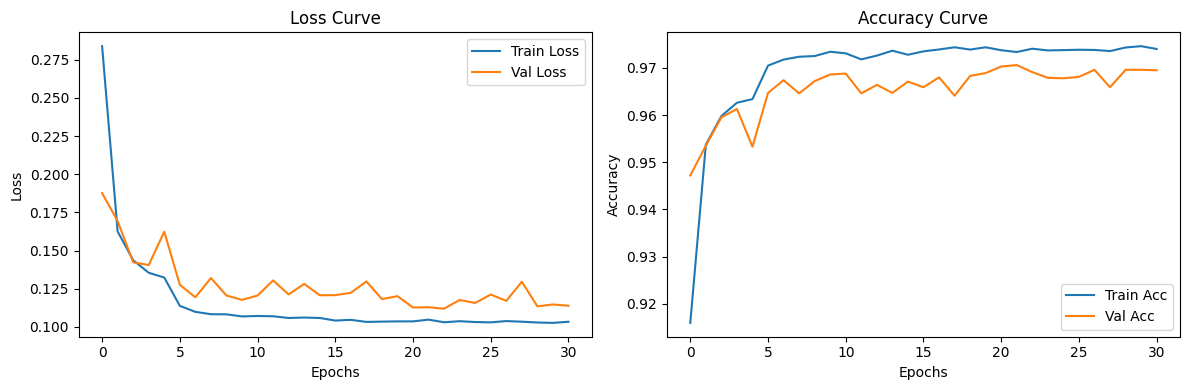

Best train set accuracy: 0.9746081253998721
Best validation set accuracy: 0.9706


In [14]:
nHidden = [128, 128]
trainer_5 = train_model(nHidden)
print("Best train set accuracy:", max(trainer_5.train_scores))
print("Best validation set accuracy:", trainer_5.best_score)

## nHidden = [128, 128, 128]

best accuracy performence has been updated: 0.00000 --> 0.94470
Epoch 1/100:
[Train] loss: 0.27931, score: 0.91479
[Dev] loss: 0.18929, score: 0.94470
best accuracy performence has been updated: 0.94470 --> 0.95880
Epoch 2/100:
[Train] loss: 0.15674, score: 0.95355
[Dev] loss: 0.15062, score: 0.95880
best accuracy performence has been updated: 0.95880 --> 0.96180
Epoch 3/100:
[Train] loss: 0.13932, score: 0.95833
[Dev] loss: 0.13378, score: 0.96180
Epoch 4/100:
[Train] loss: 0.13096, score: 0.96183
[Dev] loss: 0.13663, score: 0.96020
Epoch 5/100:
[Train] loss: 0.12660, score: 0.96251
[Dev] loss: 0.14798, score: 0.95660
best accuracy performence has been updated: 0.96180 --> 0.97080
Epoch 6/100:
[Train] loss: 0.10253, score: 0.97175
[Dev] loss: 0.10498, score: 0.97080
best accuracy performence has been updated: 0.97080 --> 0.97160
Epoch 7/100:
[Train] loss: 0.09633, score: 0.97421
[Dev] loss: 0.10436, score: 0.97160
Epoch 8/100:
[Train] loss: 0.09518, score: 0.97417
[Dev] loss: 0.10623,

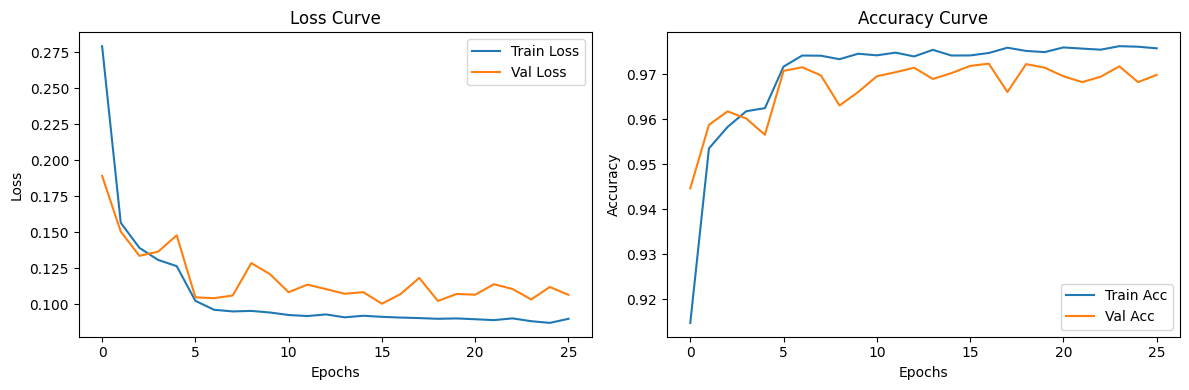

Best train set accuracy: 0.976287587971849
Best validation set accuracy: 0.9724


In [15]:
nHidden = [128, 128, 128]
trainer_6 = train_model(nHidden)
print("Best train set accuracy:", max(trainer_6.train_scores))
print("Best validation set accuracy:", trainer_6.best_score)

best accuracy performence has been updated: 0.00000 --> 0.09930
Epoch 1/100:
[Train] loss: 2.44230, score: 0.10925
[Dev] loss: 2.30306, score: 0.09930
best accuracy performence has been updated: 0.09930 --> 0.11720
Epoch 2/100:
[Train] loss: 2.30210, score: 0.10691
[Dev] loss: 2.30352, score: 0.11720
Epoch 3/100:
[Train] loss: 2.30220, score: 0.10889
[Dev] loss: 2.30201, score: 0.10080
Epoch 4/100:
[Train] loss: 2.30243, score: 0.10819
[Dev] loss: 2.30265, score: 0.11720
Epoch 5/100:
[Train] loss: 2.30224, score: 0.10903
[Dev] loss: 2.30376, score: 0.10080
Epoch 6/100:
[Train] loss: 2.30175, score: 0.11002
[Dev] loss: 2.30330, score: 0.10080
Epoch 7/100:
[Train] loss: 2.30168, score: 0.11096
[Dev] loss: 2.30228, score: 0.11720
Epoch 8/100:
[Train] loss: 2.30176, score: 0.10978
[Dev] loss: 2.30259, score: 0.11720
Epoch 9/100:
[Train] loss: 2.30172, score: 0.10978
[Dev] loss: 2.30274, score: 0.09370
Epoch 10/100:
[Train] loss: 2.30167, score: 0.10966
[Dev] loss: 2.30192, score: 0.11720
E

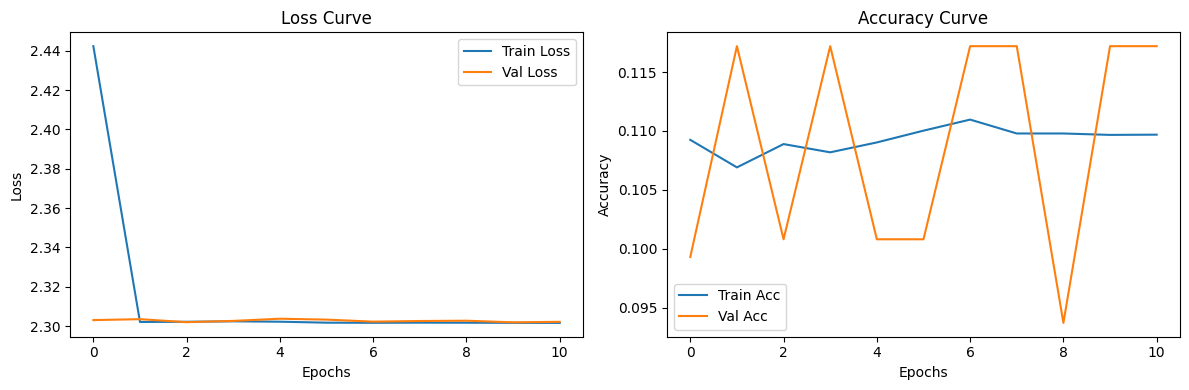

Best train set accuracy: 0.11096449136276391
Best validation set accuracy: 0.1172


In [23]:
nHidden = [128, 128, 128]
trainer_6_5 = train_model(nHidden, initialize_method='Normal')
print("Best train set accuracy:", max(trainer_6_5.train_scores))
print("Best validation set accuracy:", trainer_6_5.best_score)

#### 一个合适的初始化方式是十分重要的，在Hidden[128,128,128],使用He初始化方法得到的验证集的accuracy为0.97，而使用Normal初始化方法得到的验证集的accuracy为0.12

## nHidden = [256]

best accuracy performence has been updated: 0.00000 --> 0.94050
Epoch 1/100:
[Train] loss: 0.30784, score: 0.91221
[Dev] loss: 0.22024, score: 0.94050
best accuracy performence has been updated: 0.94050 --> 0.94540
Epoch 2/100:
[Train] loss: 0.18772, score: 0.94914
[Dev] loss: 0.19601, score: 0.94540
best accuracy performence has been updated: 0.94540 --> 0.95260
Epoch 3/100:
[Train] loss: 0.17079, score: 0.95487
[Dev] loss: 0.17218, score: 0.95260
best accuracy performence has been updated: 0.95260 --> 0.95560
Epoch 4/100:
[Train] loss: 0.16387, score: 0.95761
[Dev] loss: 0.17054, score: 0.95560
best accuracy performence has been updated: 0.95560 --> 0.95570
Epoch 5/100:
[Train] loss: 0.16004, score: 0.95847
[Dev] loss: 0.16923, score: 0.95570
best accuracy performence has been updated: 0.95570 --> 0.95890
Epoch 6/100:
[Train] loss: 0.14825, score: 0.96349
[Dev] loss: 0.15933, score: 0.95890
best accuracy performence has been updated: 0.95890 --> 0.95980
Epoch 7/100:
[Train] loss: 0.1

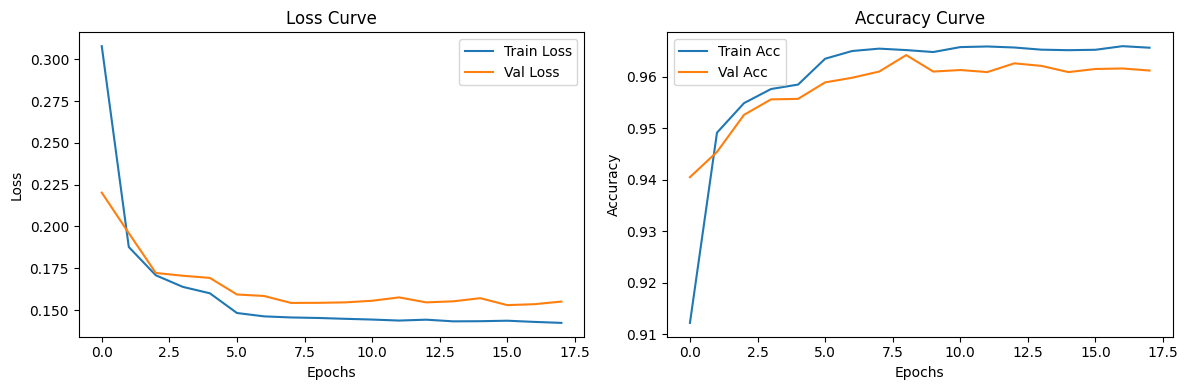

Best train set accuracy: 0.9659309021113244
Best validation set accuracy: 0.9642


In [16]:
nHidden = [256]
trainer_7 = train_model(nHidden)
print("Best train set accuracy:", max(trainer_7.train_scores))
print("Best validation set accuracy:", trainer_7.best_score)

## He 初始化

### He 初始化适用于 ReLU 激活函数，目的是防止梯度消失或爆炸

$$
W \sim \mathcal{N}\left(0, \frac{2}{n_{\text{in}}}\right)
$$

$$
f(w) = \sqrt{\frac{n_{\text{in}}}{4\pi}} \exp\left(-\frac{n_{\text{in}} w^2}{4}\right)
$$

其中$n_{\text{in}}$ 表示前一层的输入神经元数量。

best accuracy performence has been updated: 0.00000 --> 0.93770
Epoch 1/100:
[Train] loss: 0.31636, score: 0.90927
[Dev] loss: 0.21822, score: 0.93770
best accuracy performence has been updated: 0.93770 --> 0.94970
Epoch 2/100:
[Train] loss: 0.19347, score: 0.94718
[Dev] loss: 0.18915, score: 0.94970
best accuracy performence has been updated: 0.94970 --> 0.95440
Epoch 3/100:
[Train] loss: 0.17371, score: 0.95353
[Dev] loss: 0.17130, score: 0.95440
Epoch 4/100:
[Train] loss: 0.16693, score: 0.95623
[Dev] loss: 0.17219, score: 0.95360
best accuracy performence has been updated: 0.95440 --> 0.95710
Epoch 5/100:
[Train] loss: 0.16321, score: 0.95727
[Dev] loss: 0.16761, score: 0.95710
best accuracy performence has been updated: 0.95710 --> 0.95760
Epoch 6/100:
[Train] loss: 0.15136, score: 0.96211
[Dev] loss: 0.16083, score: 0.95760
Epoch 7/100:
[Train] loss: 0.14855, score: 0.96393
[Dev] loss: 0.16279, score: 0.95710
best accuracy performence has been updated: 0.95760 --> 0.95940
Epoch 8

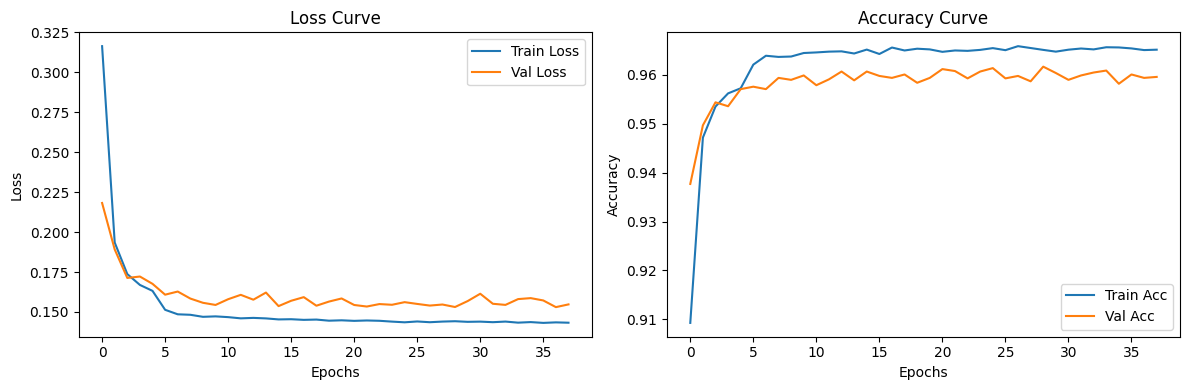

Best train set accuracy: 0.9658909149072297
Best validation set accuracy: 0.9617


In [17]:
trainer_He = train_model(nHidden=[128], initialize_method='He')
print("Best train set accuracy:", max(trainer_He.train_scores))
print("Best validation set accuracy:", trainer_He.best_score)

## Normal初始化

$$
W \sim \mathcal{N}(0, \sigma^2)
$$

$$
f(w) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{w^2}{2\sigma^2}\right)
$$


best accuracy performence has been updated: 0.00000 --> 0.91530
Epoch 1/100:
[Train] loss: 1.06262, score: 0.85821
[Dev] loss: 0.29051, score: 0.91530
best accuracy performence has been updated: 0.91530 --> 0.94120
Epoch 2/100:
[Train] loss: 0.21545, score: 0.93634
[Dev] loss: 0.20691, score: 0.94120
best accuracy performence has been updated: 0.94120 --> 0.94950
Epoch 3/100:
[Train] loss: 0.18085, score: 0.95130
[Dev] loss: 0.18369, score: 0.94950
best accuracy performence has been updated: 0.94950 --> 0.95300
Epoch 4/100:
[Train] loss: 0.16958, score: 0.95633
[Dev] loss: 0.18097, score: 0.95300
best accuracy performence has been updated: 0.95300 --> 0.95390
Epoch 5/100:
[Train] loss: 0.16594, score: 0.95733
[Dev] loss: 0.16943, score: 0.95390
best accuracy performence has been updated: 0.95390 --> 0.95940
Epoch 6/100:
[Train] loss: 0.15386, score: 0.96177
[Dev] loss: 0.15999, score: 0.95940
Epoch 7/100:
[Train] loss: 0.15168, score: 0.96271
[Dev] loss: 0.16001, score: 0.95890
best ac

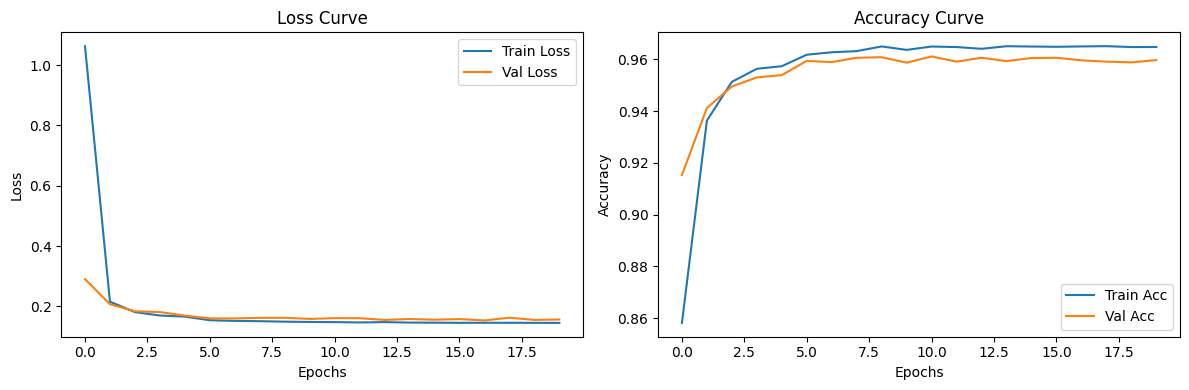

Best train set accuracy: 0.9650711772232885
Best validation set accuracy: 0.9611


In [18]:
trainer_Normal = train_model(nHidden=[128],initialize_method='Normal')
print("Best train set accuracy:", max(trainer_Normal.train_scores))
print("Best validation set accuracy:", trainer_Normal.best_score)

## Xavier 初始化

$$
W \sim \mathcal{N}\left(0, \frac{1}{n_{\text{in}} + n_{\text{out}}}\right)
$$


best accuracy performence has been updated: 0.00000 --> 0.94180
Epoch 1/100:
[Train] loss: 0.31835, score: 0.90805
[Dev] loss: 0.21505, score: 0.94180
best accuracy performence has been updated: 0.94180 --> 0.95030
Epoch 2/100:
[Train] loss: 0.19833, score: 0.94542
[Dev] loss: 0.18732, score: 0.95030
best accuracy performence has been updated: 0.95030 --> 0.95260
Epoch 3/100:
[Train] loss: 0.17808, score: 0.95306
[Dev] loss: 0.17453, score: 0.95260
Epoch 4/100:
[Train] loss: 0.16859, score: 0.95633
[Dev] loss: 0.17570, score: 0.95260
best accuracy performence has been updated: 0.95260 --> 0.95400
Epoch 5/100:
[Train] loss: 0.16228, score: 0.95793
[Dev] loss: 0.17549, score: 0.95400
best accuracy performence has been updated: 0.95400 --> 0.95950
Epoch 6/100:
[Train] loss: 0.15133, score: 0.96261
[Dev] loss: 0.16301, score: 0.95950
Epoch 7/100:
[Train] loss: 0.14860, score: 0.96411
[Dev] loss: 0.15930, score: 0.95940
Epoch 8/100:
[Train] loss: 0.14848, score: 0.96329
[Dev] loss: 0.16372,

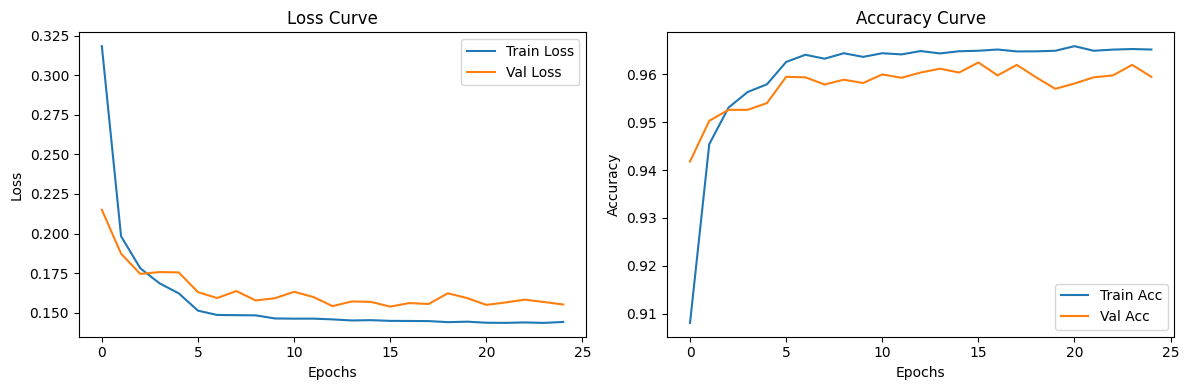

Best train set accuracy: 0.9659109085092771
Best validation set accuracy: 0.9625


In [19]:
trainer_Xavier = train_model(nHidden=[128], initialize_method = 'Xavier')
print("Best train set accuracy:", max(trainer_Xavier.train_scores))
print("Best validation set accuracy:", trainer_Xavier.best_score)

### 对比

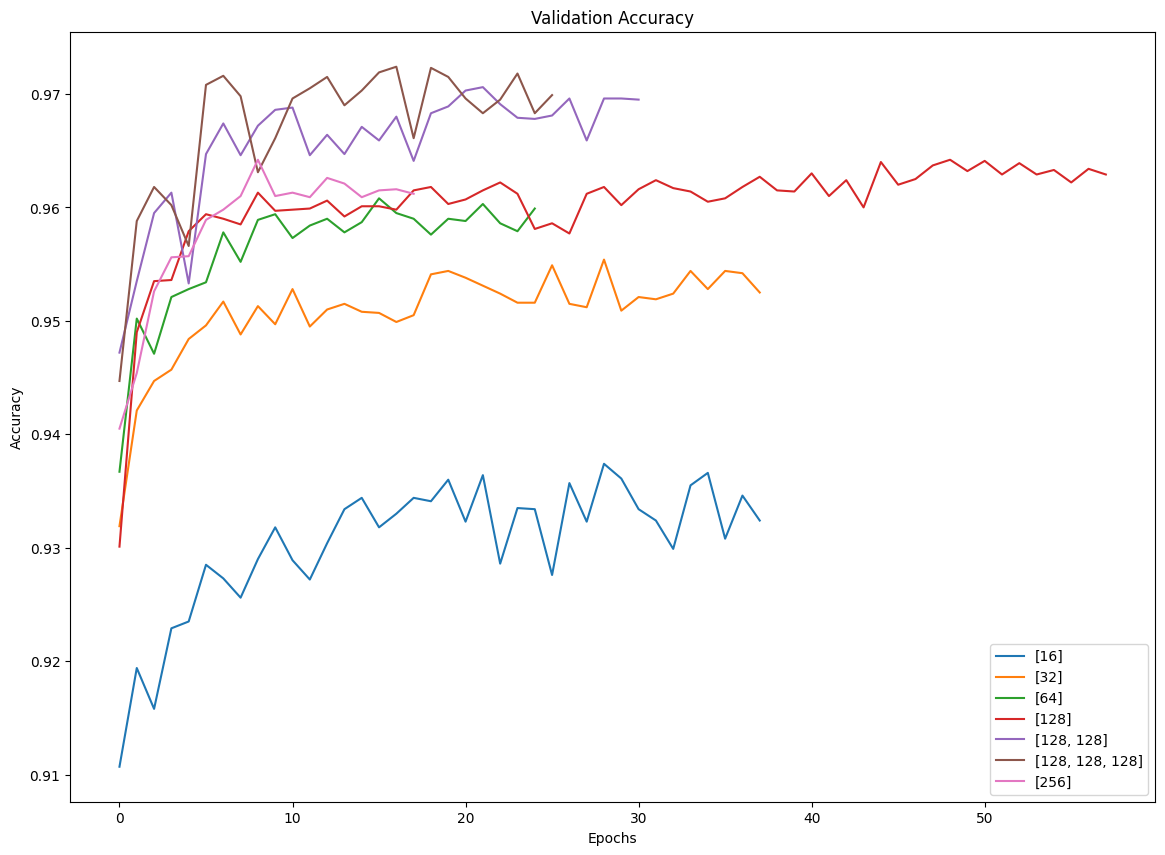

In [26]:
# Plotting the results
plt.figure(figsize=(14, 10))
plt.plot(trainer_1.dev_scores, label='[16]')
plt.plot(trainer_2.dev_scores, label='[32]')
plt.plot(trainer_3.dev_scores, label='[64]')
plt.plot(trainer_4.dev_scores, label='[128]')
plt.plot(trainer_5.dev_scores, label='[128, 128]')
plt.plot(trainer_6.dev_scores, label='[128, 128, 128]')
plt.plot(trainer_7.dev_scores, label='[256]')

plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

###### 虽然曲线比较难看，但是我认为可以通过增加log的次数来解决，但是依旧能看出整体的趋势, [128, 128, 128]准确率最高

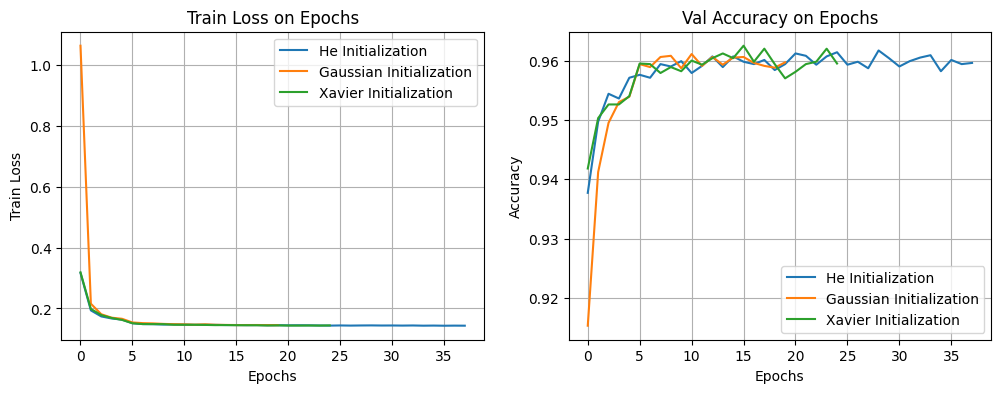

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(trainer_He.train_loss, label="He Initialization")
ax1.plot(trainer_Normal.train_loss, label="Gaussian Initialization")
ax1.plot(trainer_Xavier.train_loss, label="Xavier Initialization")
ax1.set_title("Train Loss on Epochs")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Train Loss")
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(trainer_He.dev_scores, label="He Initialization")
ax2.plot(trainer_Normal.dev_scores, label="Gaussian Initialization")
ax2.plot(trainer_Xavier.dev_scores, label="Xavier Initialization")
ax2.set_title("Val Accuracy on Epochs")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

# 显示图像
plt.show()